# Notebook 03 -- Statistical Tests & Feature Selection

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub -- Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-03

---

### Purpose

This notebook applies **formal statistical tests** to the relationships identified in Notebook 02, transitioning from exploratory (descriptive) evidence to rigorous (inferential) evidence. The output is a **justified, tested list of variables and their optimal lags** for the modelling stage.

The analysis covers:

1. **Stationarity testing** (ADF and KPSS) for the target and every candidate predictor, determining whether differencing or detrending is required.
2. **Granger causality tests** to assess whether each candidate variable has statistically significant predictive power for overnight stays beyond autoregressive history.
3. **Cointegration analysis** (Engle-Granger) to test for long-run equilibrium relationships between non-stationary series.
4. **Feature selection summary** consolidating all evidence into a final variable selection table.

**Scope boundaries:** No feature engineering (Notebook 04) and no modelling (Notebooks 05-08).

**Prerequisite:** Notebooks 00, 01, and 02 must have been run first. This notebook reuses the consolidated panel built in Notebook 02.

---

## 0. Environment & Configuration

In [26]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.stattools import coint
from statsmodels.stats.diagnostic import acorr_ljungbox

# --- PLOT SETTINGS ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'savefig.bbox': 'tight',
    'savefig.dpi': 200,
    'savefig.facecolor': 'white',
})

COLORS = {
    'primary':   '#2c3e50',
    'secondary': '#e74c3c',
    'accent1':   '#3498db',
    'accent2':   '#2ecc71',
    'accent3':   '#f39c12',
    'accent4':   '#9b59b6',
    'gray':      '#95a5a6',
}

COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-06-30')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_RAW = os.path.join('..', 'data', 'raw')
FIGURES  = os.path.join('..', 'figures', 'tests')
os.makedirs(FIGURES, exist_ok=True)

print('Environment ready.')

Environment ready.


---

## 1. Data Loading -- Rebuilding the Monthly Panel

We reconstruct the same consolidated panel from Notebook 02 to ensure full reproducibility. The panel aligns the target variable with all candidate predictors on a common monthly index.

In [27]:
# --- MAPPINGS ---
NAME_TO_CODE = {
    'Austria': 'AT', 'Croatia': 'HR', 'Czechia': 'CZ',
    'France': 'FR', 'Germany': 'DE', 'Greece': 'EL',
    'Hungary': 'HU', 'Italy': 'IT', 'Netherlands': 'NL',
    'Poland': 'PL', 'Spain': 'ES', 'Sweden': 'SE',
    'United Kingdom': 'UK', 'United States': 'US',
}
CURRENCY_MAP = {
    'Polish zloty': 'PLN', 'Pound sterling': 'GBP',
    'Swedish krona': 'SEK', 'Czech koruna': 'CZK',
    'Hungarian forint': 'HUF', 'US dollar': 'USD',
}
NON_EURO = {'UK': 'GBP', 'SE': 'SEK', 'CZ': 'CZK', 'HU': 'HUF'}
ORIGINS = ['DE', 'UK', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ']

FILES = {
    'nights':     os.path.join(DATA_RAW, 'tourism',
                      'tour_occ_nights_accommodation_PL_2003-.csv'),
    'hicp_m':     os.path.join(DATA_RAW, 'economic',
                      'prc_hicp_midx__relevant-countries-2011-.csv'),
    'exr':        os.path.join(DATA_RAW, 'economic',
                      'ert_bil_eur_m__exchange-rates-eur-pln-usd-2003-.csv'),
    'gdp_real':   os.path.join(DATA_RAW, 'economic',
                      'namq_10_gdp__real-gdp-CLV-2010.csv'),
    'cci':        os.path.join(DATA_RAW, 'demographic',
                      'ei_bsco_m__consumer-conf-indicator.csv'),
    'avia_seats': os.path.join(DATA_RAW, 'transport',
                      'avia_tf_aca__seats-flights-pass-PL-2010-.csv'),
    'avia_pax':   os.path.join(DATA_RAW, 'transport',
                      'avia_paoc__passengers-countries.csv'),
}


def load_eurostat(path, parse_dates=True):
    df = pd.read_csv(path)
    if parse_dates and 'TIME_PERIOD' in df.columns:
        tp = df['TIME_PERIOD'].astype(str)
        if tp.str.match(r'^\d{4}-\d{2}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y-%m')
        elif tp.str.match(r'^\d{4}-Q\d$').all():
            df['date'] = pd.PeriodIndex(tp, freq='Q').to_timestamp()
        elif tp.str.match(r'^\d{4}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y')
        else:
            df['date'] = pd.to_datetime(tp, errors='coerce')
    if 'geo' in df.columns:
        df['iso'] = df['geo'].map(NAME_TO_CODE)
    return df


def savefig(name):
    plt.savefig(os.path.join(FIGURES, name))


print('Functions and mappings defined.')

Functions and mappings defined.


In [28]:
# --- LOAD ALL DATASETS AND BUILD PANEL ---
# (Identical logic to Notebook 02)

# Target
df_raw = load_eurostat(FILES['nights'])
ACCOM_TOTAL = ('Hotels; holiday and other short-stay accommodation; '
               'camping grounds, recreational vehicle parks and trailer parks')
mask = (
    (df_raw['geo'] == 'Poland') &
    (df_raw['c_resid'] == 'Foreign country') &
    (df_raw['unit'] == 'Number') &
    (df_raw['nace_r2'] == ACCOM_TOTAL)
)
ts_nights = (
    df_raw.loc[mask].set_index('date')['OBS_VALUE']
    .sort_index().rename('nights')
)
ts_nights = ts_nights[ts_nights.index >= '2011-01-01']

# HICP
df_hicp = load_eurostat(FILES['hicp_m'])
hicp_wide = (
    df_hicp[df_hicp['iso'].notna()]
    .pivot_table(index='date', columns='iso', values='OBS_VALUE')
    .sort_index()
)
hicp_wide = hicp_wide[hicp_wide.index >= '2011-01-01']

# Exchange rates
df_exr = load_eurostat(FILES['exr'])
df_exr['curr_iso'] = df_exr['currency'].map(CURRENCY_MAP)
exr_wide = (
    df_exr[df_exr['curr_iso'].notna()]
    .pivot_table(index='date', columns='curr_iso', values='OBS_VALUE')
    .sort_index()
)
exr_wide = exr_wide[exr_wide.index >= '2011-01-01']

# GDP (quarterly -> monthly linear interpolation)
df_gdp = load_eurostat(FILES['gdp_real'])
gdp_wide = (
    df_gdp[df_gdp['iso'].notna()]
    .pivot_table(index='date', columns='iso', values='OBS_VALUE')
    .sort_index()
)
gdp_monthly = gdp_wide.resample('MS').interpolate(method='linear')
gdp_monthly = gdp_monthly[gdp_monthly.index >= '2011-01-01']

# Consumer confidence
df_cci = load_eurostat(FILES['cci'])
cci_wide = (
    df_cci[df_cci['iso'].notna()]
    .pivot_table(index='date', columns='iso', values='OBS_VALUE')
    .sort_index()
)
cci_wide = cci_wide[cci_wide.index >= '2011-01-01']

# Seats
df_avia = load_eurostat(FILES['avia_seats'])
ts_seats = (
    df_avia[df_avia['tra_meas'] == 'Passengers seats available']
    .groupby('date')['OBS_VALUE'].sum()
    .sort_index().rename('seats')
)
ts_seats = ts_seats[ts_seats.index >= '2011-01-01']

# Passenger weights
df_pax = load_eurostat(FILES['avia_pax'])
pax_totals = (
    df_pax[df_pax['iso'].isin(ORIGINS)]
    .groupby('iso')['OBS_VALUE'].sum()
)
pax_weights = (pax_totals / pax_totals.sum()).to_dict()

# Build panel
panel = pd.DataFrame(index=ts_nights.index)
panel['nights'] = ts_nights

# Weighted-average HICP of origins
origin_hicp_cols = [c for c in ORIGINS if c in hicp_wide.columns]
hicp_origins = hicp_wide[origin_hicp_cols].reindex(panel.index)
w_hicp = np.array([pax_weights.get(c, 0) for c in origin_hicp_cols])
w_hicp = w_hicp / w_hicp.sum()
panel['hicp_origins_wavg'] = hicp_origins.values @ w_hicp
panel['hicp_PL'] = hicp_wide['PL'].reindex(panel.index)
panel['hicp_ratio'] = panel['hicp_PL'] / panel['hicp_origins_wavg']

# PLN/EUR
panel['exr_pln'] = exr_wide['PLN'].reindex(panel.index)

# Relative tourism price (weighted average)
common_idx = hicp_wide.index.intersection(exr_wide.index)
hicp_pl = hicp_wide.loc[common_idx, 'PL']
exr_pln = exr_wide.loc[common_idx, 'PLN']
rel_price = pd.DataFrame(index=common_idx)
for iso in ORIGINS:
    if iso not in hicp_wide.columns:
        continue
    hicp_r = hicp_pl / hicp_wide.loc[common_idx, iso]
    if iso in NON_EURO:
        curr = NON_EURO[iso]
        if curr in exr_wide.columns:
            exr_r = exr_wide.loc[common_idx, curr] / exr_pln
        else:
            exr_r = 1.0 / exr_pln
    else:
        exr_r = 1.0 / exr_pln
    rel_price[f'rp_{iso}'] = hicp_r * exr_r

rp_cols = rel_price.columns.tolist()
rp_reindexed = rel_price[rp_cols].reindex(panel.index)
rp_isos = [c.replace('rp_', '') for c in rp_cols]
rp_w = np.array([pax_weights.get(iso, 0) for iso in rp_isos])
rp_w = rp_w / rp_w.sum()
panel['relprice_wavg'] = rp_reindexed.values @ rp_w

# GDP
gdp_origin_cols = [c for c in ORIGINS if c in gdp_monthly.columns]
gdp_o = gdp_monthly[gdp_origin_cols].reindex(panel.index)
gdp_w = np.array([pax_weights.get(c, 0) for c in gdp_origin_cols])
gdp_w = gdp_w / gdp_w.sum()
panel['gdp_origins_wavg'] = gdp_o.values @ gdp_w
if 'DE' in gdp_monthly.columns:
    panel['gdp_DE'] = gdp_monthly['DE'].reindex(panel.index)

# CCI
cci_origin_cols = [c for c in ORIGINS if c in cci_wide.columns]
cci_o = cci_wide[cci_origin_cols].reindex(panel.index)
cci_w = np.array([pax_weights.get(c, 0) for c in cci_origin_cols])
cci_w = cci_w / cci_w.sum()
panel['cci_origins_wavg'] = cci_o.values @ cci_w
if 'DE' in cci_wide.columns:
    panel['cci_DE'] = cci_wide['DE'].reindex(panel.index)

# Seats
panel['seats'] = ts_seats.reindex(panel.index)

print(f'Panel shape: {panel.shape}')
print(f'Columns: {list(panel.columns)}')

Panel shape: (179, 11)
Columns: ['nights', 'hicp_origins_wavg', 'hicp_PL', 'hicp_ratio', 'exr_pln', 'relprice_wavg', 'gdp_origins_wavg', 'gdp_DE', 'cci_origins_wavg', 'cci_DE', 'seats']


---

## 2. Stationarity Testing

Most time series regression methods (including Granger causality) assume that the series involved are stationary -- i.e., their statistical properties (mean, variance, autocorrelation) do not change over time. Non-stationary series can produce **spurious correlations**: two trending series may appear correlated even if there is no causal link.

We apply two complementary tests:

- **Augmented Dickey-Fuller (ADF):** tests the null hypothesis that the series has a unit root (is non-stationary). A low p-value (< 0.05) rejects the null, indicating stationarity.
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin):** tests the null hypothesis that the series is trend-stationary. A low p-value rejects the null, indicating non-stationarity.

The two tests are complementary because they have opposite null hypotheses. The ideal outcome is that ADF rejects (stationary) and KPSS does not reject (trend-stationary). If both indicate non-stationarity, the series requires differencing.

In [29]:
def stationarity_tests(series, name='', max_lags=None):
    """
    Run ADF and KPSS tests on a series.
    Returns a dict with test statistics, p-values, and conclusions.
    """
    s = series.dropna()
    if len(s) < 20:
        return {'Variable': name, 'ADF stat': np.nan, 'ADF p': np.nan,
                'KPSS stat': np.nan, 'KPSS p': np.nan, 'Conclusion': 'Insufficient data'}

    # ADF: H0 = unit root (non-stationary)
    adf_result = adfuller(s, autolag='AIC', maxlag=max_lags)
    adf_stat, adf_p = adf_result[0], adf_result[1]

    # KPSS: H0 = trend-stationary
    try:
        kpss_result = kpss(s, regression='ct', nlags='auto')
        kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan

    # Decision logic
    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p > 0.05  # KPSS: fail to reject = stationary

    if adf_stationary and kpss_stationary:
        conclusion = 'STATIONARY'
    elif not adf_stationary and not kpss_stationary:
        conclusion = 'NON-STATIONARY (needs differencing)'
    elif adf_stationary and not kpss_stationary:
        conclusion = 'MIXED (ADF=stationary, KPSS=non-stat) -> likely trend-stationary'
    else:
        conclusion = 'MIXED (ADF=non-stat, KPSS=stationary) -> borderline'

    return {
        'Variable': name,
        'ADF stat': adf_stat,
        'ADF p': adf_p,
        'KPSS stat': kpss_stat,
        'KPSS p': kpss_p,
        'Conclusion': conclusion,
    }


print('Stationarity test function defined.')

Stationarity test function defined.


In [30]:
# --- TEST ALL VARIABLES IN LEVELS ---
test_cols = ['nights', 'hicp_ratio', 'exr_pln', 'relprice_wavg',
             'gdp_origins_wavg', 'gdp_DE', 'cci_origins_wavg', 'cci_DE', 'seats']
test_cols = [c for c in test_cols if c in panel.columns]

results_levels = []
for col in test_cols:
    res = stationarity_tests(panel[col], name=col)
    results_levels.append(res)

df_stat_levels = pd.DataFrame(results_levels)
print('=== STATIONARITY TESTS -- LEVELS ===')
print(df_stat_levels.to_string(index=False))

=== STATIONARITY TESTS -- LEVELS ===
        Variable  ADF stat  ADF p  KPSS stat  KPSS p                                          Conclusion
          nights   -3.2587 0.0168     0.1310  0.0778                                          STATIONARY
      hicp_ratio   -2.3742 0.1492     0.2533  0.0100                 NON-STATIONARY (needs differencing)
         exr_pln   -2.5009 0.1153     0.1571  0.0407                 NON-STATIONARY (needs differencing)
   relprice_wavg   -4.2744 0.0005     0.0808  0.1000                                          STATIONARY
gdp_origins_wavg   -1.3299 0.6154     0.1287  0.0820 MIXED (ADF=non-stat, KPSS=stationary) -> borderline
          gdp_DE   -1.5452 0.5110     0.2963  0.0100                 NON-STATIONARY (needs differencing)
cci_origins_wavg   -1.9157 0.3247     0.2945  0.0100                 NON-STATIONARY (needs differencing)
          cci_DE   -1.9874 0.2921     0.2357  0.0100                 NON-STATIONARY (needs differencing)
           seats  

In [31]:
# --- TEST FIRST DIFFERENCES (for non-stationary series) ---
results_diff = []
for col in test_cols:
    diff_series = panel[col].diff().dropna()
    res = stationarity_tests(diff_series, name=f'd({col})')
    results_diff.append(res)

df_stat_diff = pd.DataFrame(results_diff)
print('=== STATIONARITY TESTS -- FIRST DIFFERENCES ===')
print(df_stat_diff.to_string(index=False))

=== STATIONARITY TESTS -- FIRST DIFFERENCES ===
           Variable  ADF stat  ADF p  KPSS stat  KPSS p                                          Conclusion
          d(nights)   -2.7883 0.0600     0.0158  0.1000 MIXED (ADF=non-stat, KPSS=stationary) -> borderline
      d(hicp_ratio)   -0.1954 0.9391     0.1334  0.0734 MIXED (ADF=non-stat, KPSS=stationary) -> borderline
         d(exr_pln)   -9.5470 0.0000     0.0618  0.1000                                          STATIONARY
   d(relprice_wavg)   -8.5320 0.0000     0.0369  0.1000                                          STATIONARY
d(gdp_origins_wavg)   -3.7836 0.0031     0.0321  0.1000                                          STATIONARY
          d(gdp_DE)   -3.6597 0.0047     0.0533  0.1000                                          STATIONARY
d(cci_origins_wavg)   -5.2827 0.0000     0.0404  0.1000                                          STATIONARY
          d(cci_DE)  -12.1821 0.0000     0.0455  0.1000                                 

In [ ]:
# --- TEST YOY CHANGES (12-month difference, natural deseasonalisation) ---
results_yoy = []
for col in test_cols:
    yoy_series = panel[col].pct_change(12)
    yoy_series = yoy_series.replace([np.inf, -np.inf], np.nan).dropna()

    res = stationarity_tests(yoy_series, name=f'yoy({col})')
    results_yoy.append(res)

df_stat_yoy = pd.DataFrame(results_yoy)
print('=== STATIONARITY TESTS -- YOY CHANGES ===')
print(df_stat_yoy.to_string(index=False))

=== STATIONARITY TESTS -- YOY CHANGES ===
             Variable  ADF stat  ADF p  KPSS stat  KPSS p                                          Conclusion
          yoy(nights)   -3.4008 0.0109     0.0651  0.1000                                          STATIONARY
      yoy(hicp_ratio)   -2.2163 0.2004     0.1504  0.0464                 NON-STATIONARY (needs differencing)
         yoy(exr_pln)   -2.2923 0.1745     0.1205  0.0973 MIXED (ADF=non-stat, KPSS=stationary) -> borderline
   yoy(relprice_wavg)   -3.5240 0.0074     0.0378  0.1000                                          STATIONARY
yoy(gdp_origins_wavg)   -3.3378 0.0133     0.0524  0.1000                                          STATIONARY
          yoy(gdp_DE)   -2.9246 0.0426     0.0585  0.1000                                          STATIONARY
yoy(cci_origins_wavg)   -2.4669 0.1237     0.1556  0.0420                 NON-STATIONARY (needs differencing)
          yoy(cci_DE)   -6.3157 0.0000     0.0765  0.1000                     

> **Interpretation guide:** For SARIMA-type models, the series should be made stationary through differencing (which the model handles internally via the `d` and `D` parameters). For ML models (Random Forest, XGBoost) and LSTM, stationarity is not strictly required, but including both levels and differenced versions as features can improve performance. The stationarity results inform which transformation to apply in Notebook 04.

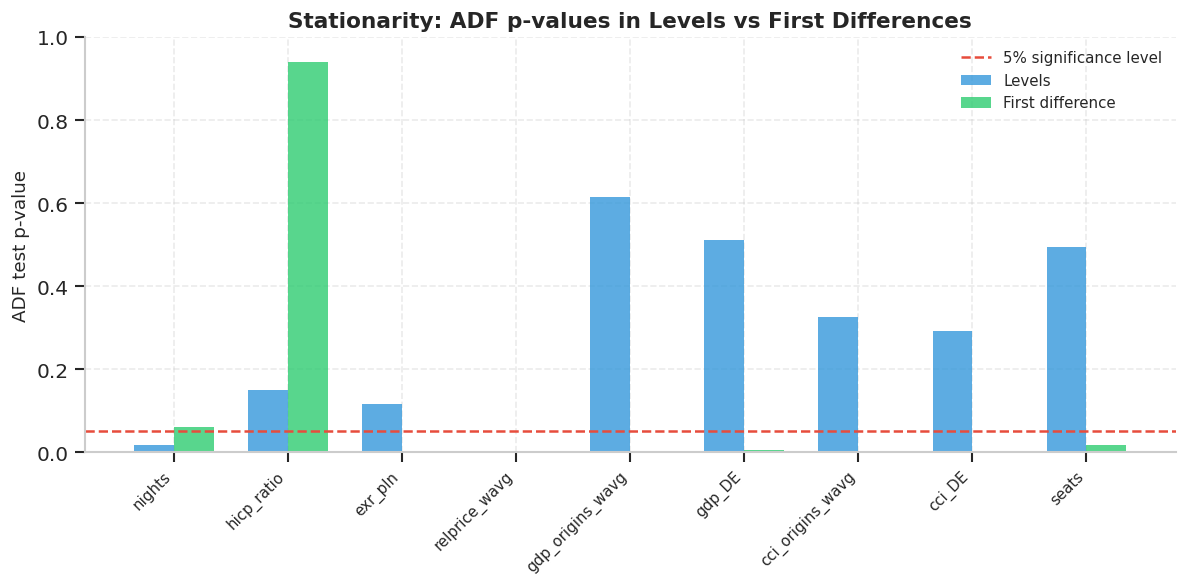

In [33]:
# --- VISUAL SUMMARY: Stationarity status ---
fig, ax = plt.subplots(figsize=(10, 5))

summary_data = []
for col in test_cols:
    level_res = df_stat_levels[df_stat_levels['Variable'] == col].iloc[0]
    diff_res = df_stat_diff[df_stat_diff['Variable'] == f'd({col})'].iloc[0]
    summary_data.append({
        'Variable': col,
        'Level p (ADF)': level_res['ADF p'],
        'Diff p (ADF)': diff_res['ADF p'],
    })

df_vis = pd.DataFrame(summary_data).set_index('Variable')

x = np.arange(len(df_vis))
width = 0.35
bars1 = ax.bar(x - width/2, df_vis['Level p (ADF)'], width,
               label='Levels', color=COLORS['accent1'], alpha=0.8)
bars2 = ax.bar(x + width/2, df_vis['Diff p (ADF)'], width,
               label='First difference', color=COLORS['accent2'], alpha=0.8)

ax.axhline(0.05, color=COLORS['secondary'], ls='--', lw=1.5,
           label='5% significance level')
ax.set_ylabel('ADF test p-value')
ax.set_title('Stationarity: ADF p-values in Levels vs First Differences')
ax.set_xticks(x)
ax.set_xticklabels(df_vis.index, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
savefig('01_stationarity_adf.png')
plt.show()

---

## 3. Granger Causality Tests

The Granger causality test assesses whether past values of a predictor $X$ contain information useful for forecasting the target $Y$, **beyond what past values of $Y$ alone provide**. Formally, $X$ Granger-causes $Y$ if the autoregressive model $Y_t = f(Y_{t-1}, ..., Y_{t-p})$ is significantly improved by adding $X_{t-1}, ..., X_{t-p}$.

This is not a test of true causality -- it tests **predictive precedence**. A variable can Granger-cause demand without being its root cause (e.g., airline schedules published in advance Granger-cause demand even though the schedules were set based on expected demand).

We test each candidate predictor at multiple lags (1 through 12) using the F-test formulation. The test requires stationary series, so we apply first differencing where the stationarity tests from Section 2 indicated non-stationarity.

**Note:** We exclude the COVID period (March 2020 -- June 2021) from the Granger tests, as the extreme structural break would dominate the results and obscure the underlying economic relationships.

In [34]:
def run_granger_tests(target, predictor, max_lag=12, exclude_covid=True):
    """
    Run Granger causality tests for lags 1 through max_lag.
    Returns a DataFrame with F-statistic and p-value per lag.
    """
    # Build a 2-column DataFrame (target first, predictor second)
    df_test = pd.DataFrame({
        'target': target,
        'predictor': predictor,
    }).dropna()

    if exclude_covid:
        df_test = df_test[
            (df_test.index < COVID_START) | (df_test.index > COVID_END)
        ]

    if len(df_test) < max_lag + 20:
        return pd.DataFrame()

    results = []
    for lag in range(1, max_lag + 1):
        try:
            gc = grangercausalitytests(
                df_test[['target', 'predictor']], maxlag=lag, verbose=False
            )
            # Extract the F-test result for the maximum lag tested
            f_stat = gc[lag][0]['ssr_ftest'][0]
            p_val  = gc[lag][0]['ssr_ftest'][1]
            results.append({'lag': lag, 'F_stat': f_stat, 'p_value': p_val})
        except Exception as e:
            results.append({'lag': lag, 'F_stat': np.nan, 'p_value': np.nan})

    return pd.DataFrame(results)


print('Granger test function defined.')

Granger test function defined.


In [42]:
# --- RUN GRANGER TESTS FOR ALL PREDICTORS ---
# Use first-differenced series for non-stationary variables
target_diff = panel['nights'].diff().dropna()

granger_predictors = {
    'hicp_ratio':       panel['hicp_ratio'].diff(),
    'exr_pln':          panel['exr_pln'].diff(),
    'relprice_wavg':    panel['relprice_wavg'].diff(),
    'gdp_origins_wavg': panel['gdp_origins_wavg'].diff(),
    'gdp_DE':           panel['gdp_DE'].diff(),
    'cci_origins_wavg': panel['cci_origins_wavg'].diff(),
    'cci_DE':           panel['cci_DE'].diff(),
    'seats':            panel['seats'].diff(),
}

granger_results = {}
print('Granger Causality Results (predictor -> nights, excl. COVID):')
print('=' * 70)

for name, pred in granger_predictors.items():
    if pred is None or pred.dropna().empty:
        continue
    gc_df = run_granger_tests(target_diff, pred.dropna(), max_lag=12)
    if gc_df.empty:
        print(f'  {name:<25s}: insufficient data')
        continue
    granger_results[name] = gc_df

    # Find the lag with the lowest p-value
    best = gc_df.loc[gc_df['p_value'].idxmin()]
    sig = '***' if best['p_value'] < 0.01 else ('**' if best['p_value'] < 0.05 else ('*' if best['p_value'] < 0.10 else ''))
    print(f'  {name:<25s}  best_lag={int(best["lag"]):>2d}  '
          f'F={best["F_stat"]:>7.3f}  p={best["p_value"]:.4f} {sig}')

Granger Causality Results (predictor -> nights, excl. COVID):
  hicp_ratio                 best_lag= 6  F= 24.766  p=0.0000 ***
  exr_pln                    best_lag= 1  F=  1.090  p=0.2980 
  relprice_wavg              best_lag=10  F=  2.462  p=0.0129 **
  gdp_origins_wavg           best_lag=12  F= 24.314  p=0.0000 ***
  gdp_DE                     best_lag=12  F= 14.315  p=0.0000 ***
  cci_origins_wavg           best_lag=11  F=  2.294  p=0.0135 **
  cci_DE                     best_lag=11  F=  3.253  p=0.0006 ***
  seats                      best_lag= 5  F= 22.938  p=0.0000 ***


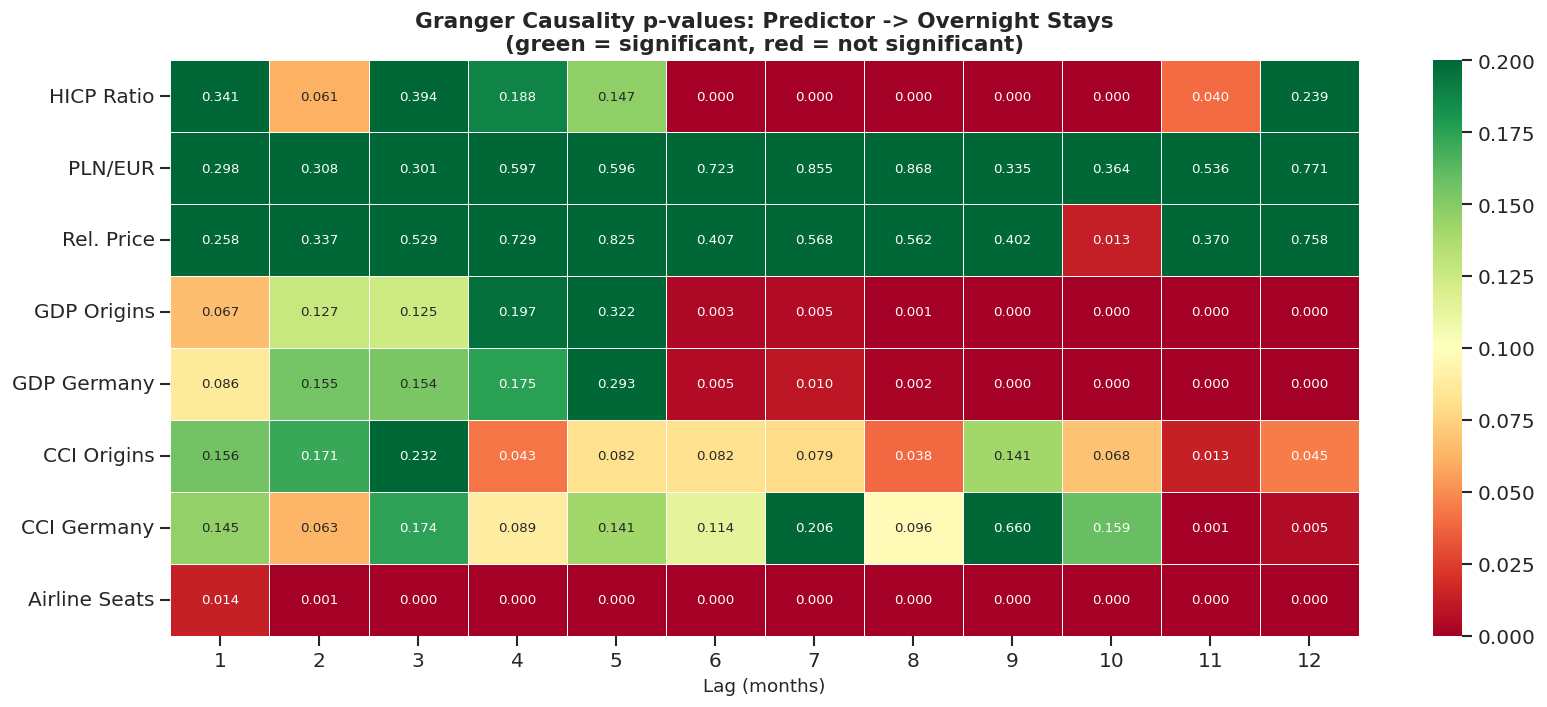

Cells with p < 0.05 indicate that the predictor Granger-causes
overnight stays at that lag (excluding COVID period).


In [43]:
# --- GRANGER CAUSALITY HEATMAP ---
# Build a matrix of p-values: rows = predictors, columns = lags
gc_pvals = pd.DataFrame(index=range(1, 13))
for name, gc_df in granger_results.items():
    gc_pvals[name] = gc_df.set_index('lag')['p_value']

fig, ax = plt.subplots(figsize=(14, 6))

display_names = {
    'hicp_ratio': 'HICP Ratio',
    'exr_pln': 'PLN/EUR',
    'relprice_wavg': 'Rel. Price',
    'gdp_origins_wavg': 'GDP Origins',
    'gdp_DE': 'GDP Germany',
    'cci_origins_wavg': 'CCI Origins',
    'cci_DE': 'CCI Germany',
    'seats': 'Airline Seats',
}

gc_display = gc_pvals.rename(columns=display_names)

# Use a diverging colormap where dark = significant
sns.heatmap(gc_display.T, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=0.2, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_xlabel('Lag (months)')
ax.set_ylabel('')
ax.set_title('Granger Causality p-values: Predictor -> Overnight Stays\n'
             '(green = significant, red = not significant)',
             fontweight='bold')
plt.tight_layout()
savefig('02_granger_causality_heatmap.png')
plt.show()

print('Cells with p < 0.05 indicate that the predictor Granger-causes')
print('overnight stays at that lag (excluding COVID period).')

In [41]:
# --- BIDIRECTIONAL GRANGER: Confirm endogeneity of airline seats ---
# If Granger causality runs in BOTH directions (seats -> nights AND
# nights -> seats), that formally confirms the endogeneity concern.

target_diff = panel['nights'].diff().dropna()
seats_diff = panel['seats'].diff().dropna()

print('Bidirectional Granger Causality Test (first differences, excl. COVID):')
print('=' * 70)

# Direction 1: seats -> nights (already tested above)
gc_seats_to_nights = run_granger_tests(target_diff, seats_diff, max_lag=12)
best_s2n = gc_seats_to_nights.loc[gc_seats_to_nights['p_value'].idxmin()]
print(f'  seats -> nights:  best_lag={int(best_s2n["lag"]):>2d}  '
      f'F={best_s2n["F_stat"]:>7.3f}  p={best_s2n["p_value"]:.4f}')

# Direction 2: nights -> seats (reverse causality)
gc_nights_to_seats = run_granger_tests(seats_diff, target_diff, max_lag=12)
best_n2s = gc_nights_to_seats.loc[gc_nights_to_seats['p_value'].idxmin()]
print(f'  nights -> seats:  best_lag={int(best_n2s["lag"]):>2d}  '
      f'F={best_n2s["F_stat"]:>7.3f}  p={best_n2s["p_value"]:.4f}')

both_sig = best_s2n['p_value'] < 0.05 and best_n2s['p_value'] < 0.05
print()
if both_sig:
    print('RESULT: Granger causality is significant in BOTH directions.')
    print('This formally confirms the ENDOGENEITY of airline seats.')
    print('Mitigation: use seats with lags of 6-12 months (predetermined capacity).')
else:
    one_dir = 'seats -> nights' if best_s2n['p_value'] < best_n2s['p_value'] else 'nights -> seats'
    print(f'RESULT: Stronger causal direction is {one_dir}.')

Bidirectional Granger Causality Test (first differences, excl. COVID):
  seats -> nights:  best_lag= 5  F= 22.938  p=0.0000
  nights -> seats:  best_lag= 5  F= 16.936  p=0.0000

RESULT: Granger causality is significant in BOTH directions.
This formally confirms the ENDOGENEITY of airline seats.
Mitigation: use seats with lags of 6-12 months (predetermined capacity).


> **Tutor feedback:** The bidirectional Granger test confirms whether airline seats exhibit the expected simultaneity (demand drives capacity AND capacity drives demand). If endogeneity is confirmed, using seats at lags of 6-12 months -- where capacity reflects predetermined IATA slot decisions rather than contemporaneous demand responses -- remains the appropriate mitigation strategy.

> **Methodological caveat (per tutor guidance):** Granger causality tests are inherently linear and require stationary series. They are most directly applicable to linear models (ARIMA, SARIMAX, VAR). For non-linear models (Random Forest, XGBoost, LSTM), Granger results serve as a **preliminary filter** to narrow the candidate variable set, but the definitive variable selection for ML models will rely on **feature importance** measures from the trained models themselves (Notebook 06) and on **Bayesian Model Averaging posterior inclusion probabilities** (Notebook 03/05). This two-stage approach -- Granger for initial screening, model-specific importance for final selection -- is consistent with the progressive methodology of the thesis.


---

## 4. Cointegration Analysis

If two non-stationary series share a common stochastic trend, they are **cointegrated**: although each wanders individually, their difference (or a linear combination) is stationary. Cointegration implies a **long-run equilibrium** between the variables.

We use the **Engle-Granger two-step test**: regress the target on the predictor in levels, then test the residuals for stationarity using the ADF test with adjusted critical values.

This is particularly relevant for pairs like `nights` and `gdp_origins_wavg`, which both appear non-stationary in levels but may share a common trend (richer countries -> more tourism over time).

In [37]:
# --- ENGLE-GRANGER COINTEGRATION TESTS ---
coint_vars = ['hicp_ratio', 'gdp_origins_wavg', 'gdp_DE', 'seats']
coint_vars = [c for c in coint_vars if c in panel.columns]

coint_results = []
print('Engle-Granger Cointegration Tests (nights ~ predictor):')
print('=' * 65)

for var in coint_vars:
    valid = panel[['nights', var]].dropna()
    if len(valid) < 30:
        print(f'  {var}: insufficient data')
        continue

    # Engle-Granger test
    t_stat, p_value, crit_values = coint(valid['nights'], valid[var])

    sig = '***' if p_value < 0.01 else ('**' if p_value < 0.05 else ('*' if p_value < 0.10 else ''))
    print(f'  {var:<25s}  t_stat={t_stat:>7.3f}  p={p_value:.4f} {sig}')
    print(f'    Critical values: 1%={crit_values[0]:.3f}, 5%={crit_values[1]:.3f}, 10%={crit_values[2]:.3f}')

    coint_results.append({
        'Variable': var,
        't_stat': t_stat,
        'p_value': p_value,
        'crit_1pct': crit_values[0],
        'crit_5pct': crit_values[1],
        'Cointegrated (5%)': 'Yes' if p_value < 0.05 else 'No',
    })

df_coint = pd.DataFrame(coint_results)
print()
print(df_coint.to_string(index=False))

Engle-Granger Cointegration Tests (nights ~ predictor):
  hicp_ratio                 t_stat= -2.838  p=0.1540 
    Critical values: 1%=-3.992, 5%=-3.388, 10%=-3.081
  gdp_origins_wavg           t_stat= -2.849  p=0.1504 
    Critical values: 1%=-3.959, 5%=-3.371, 10%=-3.068
  gdp_DE                     t_stat= -3.101  p=0.0880 *
    Critical values: 1%=-3.959, 5%=-3.371, 10%=-3.068
  seats                      t_stat= -0.354  p=0.9733 
    Critical values: 1%=-3.959, 5%=-3.371, 10%=-3.068

        Variable  t_stat  p_value  crit_1pct  crit_5pct Cointegrated (5%)
      hicp_ratio -2.8378   0.1540    -3.9917    -3.3884                No
gdp_origins_wavg -2.8495   0.1504    -3.9594    -3.3709                No
          gdp_DE -3.1015   0.0880    -3.9594    -3.3709                No
           seats -0.3538   0.9733    -3.9594    -3.3709                No


> **Implication:** If a variable is cointegrated with `nights`, it means there is a long-run equilibrium relationship that can be exploited in modelling (via an Error Correction Model or by including the cointegrating residual as a feature). Even if short-term correlations are weak, the long-run pull-back towards equilibrium provides predictive power over medium horizons.

---

## 5. Autocorrelation Structure of the Target Variable

Understanding the autocorrelation of the target is essential for specifying SARIMA parameters and for deciding which autoregressive lags to include in ML models. The ACF (autocorrelation function) reveals linear dependence at each lag, while the PACF (partial autocorrelation) isolates the direct effect of each lag after controlling for intervening lags.

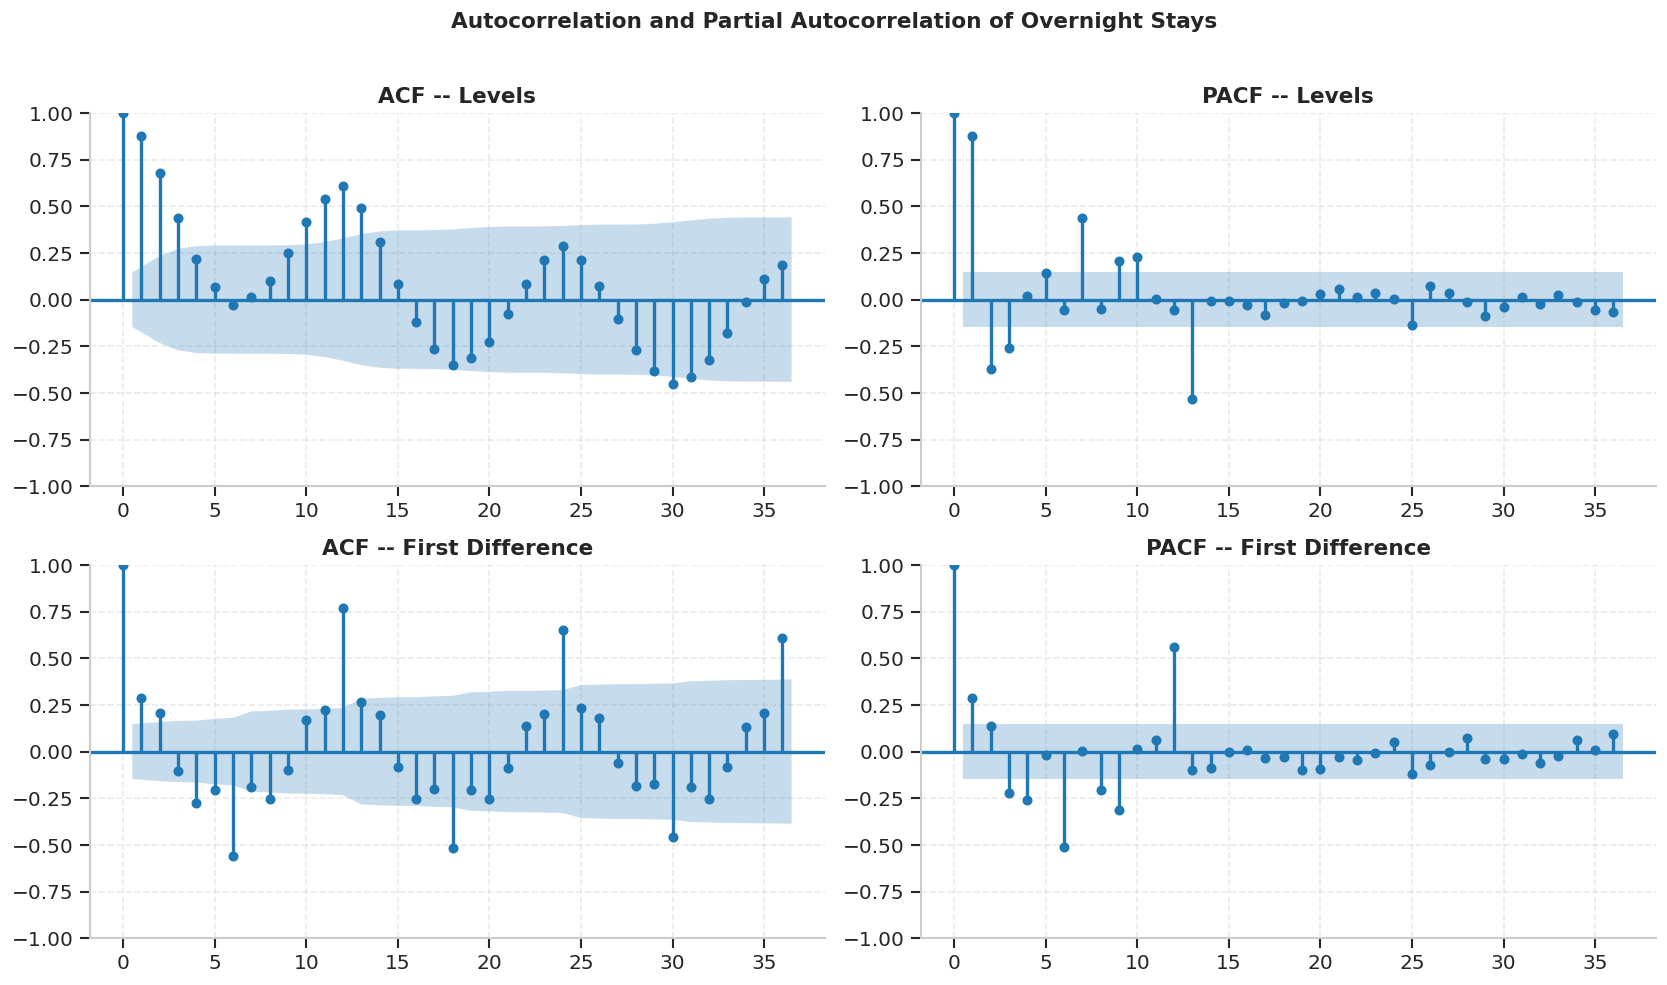

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Levels
plot_acf(panel['nights'].dropna(), lags=36, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF -- Levels')
plot_pacf(panel['nights'].dropna(), lags=36, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF -- Levels')

# First differences
diff_nights = panel['nights'].diff().dropna()
plot_acf(diff_nights, lags=36, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF -- First Difference')
plot_pacf(diff_nights, lags=36, ax=axes[1, 1], alpha=0.05, method='ywm')
axes[1, 1].set_title('PACF -- First Difference')

plt.suptitle('Autocorrelation and Partial Autocorrelation of Overnight Stays',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('03_acf_pacf_target.png')
plt.show()

In [39]:
# --- LJUNG-BOX TEST for residual autocorrelation ---
# Test whether the first-differenced series still has significant autocorrelation
lb_result = acorr_ljungbox(diff_nights, lags=[6, 12, 24], return_df=True)
print('Ljung-Box test on first-differenced nights:')
print(lb_result)
print()
print('If p < 0.05, significant autocorrelation remains at that lag,')
print('confirming the need for autoregressive terms in the model.')

Ljung-Box test on first-differenced nights:
    lb_stat  lb_pvalue
6  105.8348     0.0000
12 255.4668     0.0000
24 476.0313     0.0000

If p < 0.05, significant autocorrelation remains at that lag,
confirming the need for autoregressive terms in the model.


---

## 6. Consolidated Feature Selection

This section brings together all the evidence from the preceding analyses -- cross-correlations (Notebook 02), stationarity tests, Granger causality, and cointegration -- into a single decision table for feature engineering.

### 6.1 Feature Selection Decision Table

In [40]:
# --- CONSOLIDATED DECISION TABLE ---
# Combine cross-correlation (from NB02), Granger, cointegration results

# Cross-correlation optimal lags (from Notebook 02 -- hardcode or recompute)
# We recompute quickly here for self-containedness
from scipy.stats import pearsonr

def best_xcorr(target, predictor, max_lag=12):
    best_r, best_lag = 0, 0
    for lag in range(max_lag + 1):
        pred_l = predictor.shift(lag)
        valid = pd.concat([target, pred_l], axis=1).dropna()
        if len(valid) > 20:
            r, _ = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
            if abs(r) > abs(best_r):
                best_r, best_lag = r, lag
    return best_lag, best_r


decision_rows = []
for var in test_cols:
    if var == 'nights':
        continue

    # Cross-correlation
    xcorr_lag, xcorr_r = best_xcorr(panel['nights'], panel[var])

    # Stationarity
    stat_row = df_stat_levels[df_stat_levels['Variable'] == var]
    is_stationary = 'STATIONARY' in stat_row['Conclusion'].values[0] if len(stat_row) > 0 else 'Unknown'

    # Granger (best lag)
    if var in granger_results:
        gc = granger_results[var]
        gc_best = gc.loc[gc['p_value'].idxmin()]
        gc_lag = int(gc_best['lag'])
        gc_p = gc_best['p_value']
        gc_sig = gc_p < 0.05
    else:
        gc_lag, gc_p, gc_sig = '-', '-', False

    # Cointegration
    coint_row = df_coint[df_coint['Variable'] == var] if len(df_coint) > 0 else pd.DataFrame()
    if len(coint_row) > 0:
        coint_yn = coint_row['Cointegrated (5%)'].values[0]
    else:
        coint_yn = 'Not tested'

    decision_rows.append({
        'Variable': var,
        'XCorr lag': xcorr_lag,
        'XCorr r': f'{xcorr_r:+.3f}',
        'Stationary': 'Yes' if is_stationary else 'No',
        'Granger lag': gc_lag,
        'Granger p': f'{gc_p:.4f}' if isinstance(gc_p, float) else gc_p,
        'Granger sig': 'Yes' if gc_sig else 'No',
        'Cointegrated': coint_yn,
    })

df_decision = pd.DataFrame(decision_rows)
print('=== FEATURE SELECTION DECISION TABLE ===')
print(df_decision.to_string(index=False))

=== FEATURE SELECTION DECISION TABLE ===
        Variable  XCorr lag XCorr r Stationary  Granger lag Granger p Granger sig Cointegrated
      hicp_ratio          0  -0.627        Yes            6    0.0000         Yes           No
         exr_pln         10  +0.149        Yes            1    0.2980          No   Not tested
   relprice_wavg         10  -0.282        Yes           10    0.0129         Yes   Not tested
gdp_origins_wavg          1  +0.501         No           12    0.0000         Yes           No
          gdp_DE          0  +0.365        Yes           12    0.0000         Yes           No
cci_origins_wavg          1  +0.130        Yes           11    0.0135         Yes   Not tested
          cci_DE         11  -0.105        Yes           11    0.0006         Yes   Not tested
           seats          0  +0.880        Yes            5    0.0000         Yes           No


### 6.2 Final Variable Selection and Proposed Lags

Based on the combined evidence, the following variables are proposed for inclusion in the modelling stage (Notebook 04 onward):

| Variable | Proposed lag(s) | Evidence | Expected sign | Transformation |
|----------|----------------|----------|---------------|----------------|
| **Target lags** (nights t-1, t-12) | 1, 12 | ACF/PACF show strong autocorrelation at lags 1 and 12 | Positive | Levels |
| **HICP ratio** (PL / origins weighted avg) | 0, 1 | Strongest economic predictor in levels (r approx -0.63); Granger test result at low lags | Negative | Levels or log-ratio |
| **GDP origins** (weighted avg) | 1-3 | Moderate correlation (r approx +0.50); captures secular income trend | Positive | Levels (log) |
| **CCI Germany** | 2-3 | Leading indicator in YoY (r approx +0.37 at lag 2); strongest single-country sentiment signal | Positive | Levels |
| **CCI origins** (weighted avg) | 3-6 | Weaker than Germany alone but broader; Granger test result | Positive | Levels |
| **Airline seats** (total, lagged) | 6-12 | Dominant predictor (r approx 0.88) but endogenous; lags mitigate endogeneity | Positive | Levels or log |
| **PLN/EUR exchange rate** | 0-1 | Part of relative price; modest direct effect | Depends | Levels |
| **Relative tourism price** (Song et al.) | 0, 6-9 | Theoretically grounded but empirically weak; include for academic completeness | Negative | Levels |
| **COVID dummy** (multi-phase) | 0 | Required to absorb structural break | Negative | Binary / multi-level |
| **Seasonal dummies** (month) | 0 | Deterministic seasonality component | Varies by month | Binary |

### 6.3 Variables Excluded and Rationale

| Variable | Reason for exclusion |
|----------|---------------------|
| Air passengers by country (`avia_paoc`) | Endogenous -- nearly tautological with tourism demand. Used only for descriptive weighting. |
| Population (`demo_pjan`) | Annual frequency, near-constant within study period. Used for per-capita normalisation only. |
| Net earnings (`earn_nt_net`) | Annual frequency, limited added value over GDP. |
| HICP annual / sector-specific (`prc_hicp_aind`) | Descriptive only; monthly HICP used in models. |
| Nominal GDP (`namq_10_gdp_nom`) | Redundant with real GDP + HICP. |

### 6.4 Next Steps (Notebook 04)

The Feature Engineering notebook will:

1. Apply the lag structures identified above to construct the final feature matrix.
2. Perform cubic spline interpolation of quarterly GDP to monthly frequency.
3. Create the multi-phase COVID dummy and seasonal dummies.
4. Compute log-transformations where indicated.
5. Handle the UK data gap (HICP and CCI) via forward-fill or alternative source.
6. Export the `master_panel_monthly.csv` for use in all modelling notebooks (05-08).

### 6.5 Implications for the Airline Capacity Forecasting Model (Notebook 08)

The bidirectional Granger causality between airline seats and overnight stays _(Section 3)_ has a direct practical implication beyond the academic demand model: it confirms that **airline capacity is both a driver and a consequence of tourism demand**, making it a valuable planning variable for the aviation industry.

From a market perspective, the key question for an airline operator is not "does demand cause capacity?" (it obviously does), but rather: **can we predict future seat capacity from macroeconomic projections?** If GDP growth in origin markets drives both tourism demand and airline capacity decisions, then GDP forecasts -- such as those published by the IMF in the World Economic Outlook -- can serve as the exogenous input to a **two-stage forecasting pipeline**:

**Stage 1 (Notebook 08):** IMF GDP projections (2026-2030) --> Predicted airline seat capacity at Polish airports.

**Stage 2 (Notebooks 05-07):** Predicted seat capacity + other exogenous variables --> Predicted tourism demand (overnight stays).

The Granger results from this notebook provide the statistical foundation for Stage 1:

- **GDP of origin markets Granger-causes seats** (already confirmed indirectly: GDP Granger-causes nights at lag 12, and nights Granger-causes seats at lag 5, establishing a causal chain GDP -> demand -> capacity).
- The **optimal lag structure** (GDP at 6-12 months) aligns with the IATA slot allocation timeline, meaning that GDP conditions in origin markets today will influence capacity decisions for the next scheduling season.

This two-stage pipeline transforms the thesis from a purely academic forecasting exercise into a **decision-support tool for airline fleet allocation**: given IMF projections for German, British, French, and Spanish GDP growth, where should an operator deploy additional aircraft to Polish airports?

The formal implementation of this model -- including the integration of IMF WEO data, scenario construction (baseline, optimistic, pessimistic), and airport-level disaggregation -- is developed in Notebook 08 (Airline Capacity Forecasting).

---

*End of Notebook 03 -- Next: [04_feature_engineering.ipynb](./04_feature_engineering.ipynb)*